In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from utils import load_data, get_classification_split

TARGET = "SI"
THRESHOLD = 8

# Классификация: SI > 8

## Данные

In [2]:
df = load_data()
X_train, X_test, y_train, y_test = get_classification_split(df, TARGET, threshold=THRESHOLD)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Баланс классов (train):")
display(y_train.value_counts())

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: (800, 192), Test: (201, 192)
Баланс классов (train):


SI
0    514
1    286
Name: count, dtype: int64

## Модели

In [5]:
models = {
    "LogisticRegression": LogisticRegression(C=1.0, max_iter=5000, random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    "SVC": SVC(C=1.0, kernel="rbf", probability=True, random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}


results = []
fitted_models = {}

for name, model in models.items():
    use_scaled = name in ["LogisticRegression", "SVC", "KNN"]
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
    })
    fitted_models[name] = (model, use_scaled)

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,SVC,0.7065,0.5938,0.5352,0.5630,0.7003
1,RandomForest,0.7214,0.6316,0.5070,0.5625,0.7135
0,LogisticRegression,0.6617,0.5200,0.5493,0.5342,0.6910
4,KNN,0.6915,0.5789,0.4648,0.5156,0.7092
2,GradientBoosting,0.6965,0.5962,0.4366,0.5041,0.7009


## ROC-кривые

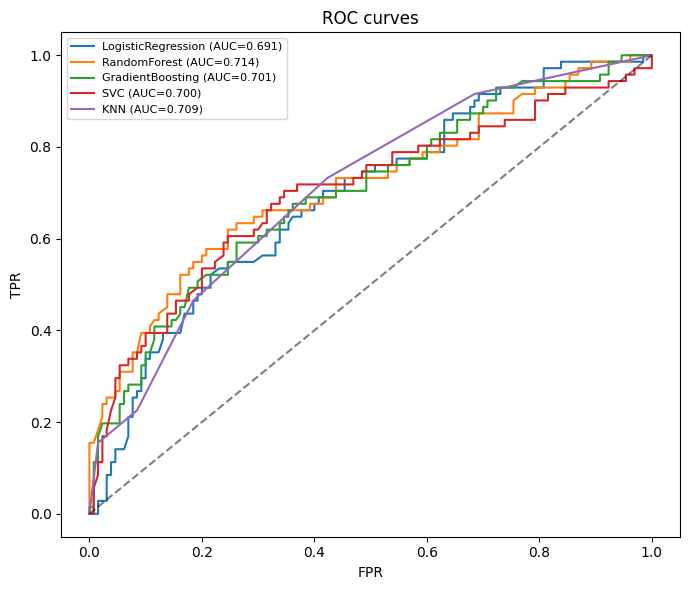

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (model, use_scaled) in fitted_models.items():
    Xte = X_test_sc if use_scaled else X_test
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC curves")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
tuned_clf = {}

svc_gs = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight="balanced"),
    {"C": [0.5, 1, 5, 10], "kernel": ["rbf", "linear"]},
    cv=5, scoring="f1", n_jobs=-1
)
svc_gs.fit(X_train_sc, y_train)
tuned_clf["SVC"] = svc_gs.best_estimator_
print(f"SVC: {svc_gs.best_params_}")

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    {"n_estimators": [200, 400], "max_depth": [8, 12, None], "min_samples_leaf": [1, 3]},
    cv=5, scoring="f1", n_jobs=-1
)
rf_gs.fit(X_train, y_train)
tuned_clf["RandomForest"] = rf_gs.best_estimator_
print(f"RF: {rf_gs.best_params_}")

for name, model in tuned_clf.items():
    Xte = X_test_sc if name == "SVC" else X_test
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    print(f"{name}: F1={f1_score(y_test, y_pred):.4f}, ROC-AUC={roc_auc_score(y_test, y_proba):.4f}")


SVC: {'C': 1, 'kernel': 'rbf'}
RF: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 400}
SVC: F1=0.5630, ROC-AUC=0.7003
RandomForest: F1=0.5625, ROC-AUC=0.7068


## Confusion matrix (лучшая модель)

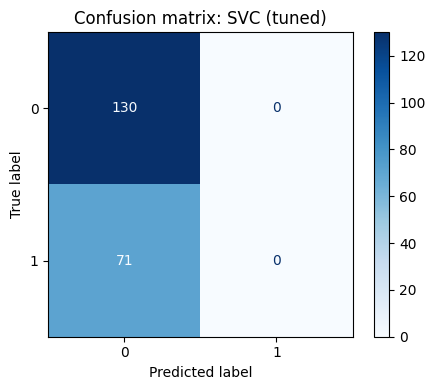

In [13]:
best_model = tuned_clf["SVC"]
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion matrix: SVC (tuned)")
plt.tight_layout()
plt.show()


## Feature importance

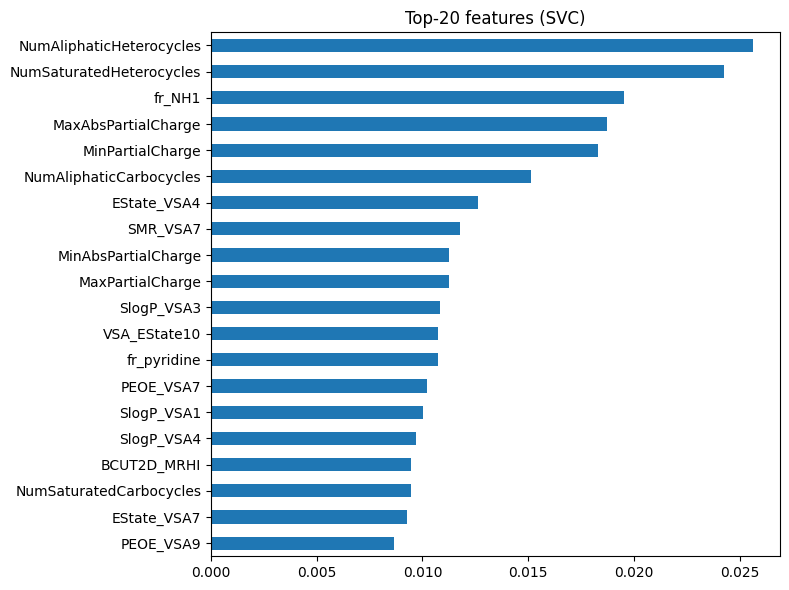

In [14]:
if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
else:
    Xte = X_test_sc if use_scaled else X_test
    perm = permutation_importance(best_model, Xte, y_test, n_repeats=10, random_state=42, scoring="f1", n_jobs=-1)
    feat_imp = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title(f"Top-20 features (SVC)")
plt.tight_layout()
plt.show()

## Подбор порога классификации

In [15]:
best_model = tuned_clf["SVC"]
y_proba = best_model.predict_proba(X_test_sc)[:, 1]

thresholds = np.arange(0.3, 0.7, 0.05)
thresh_results = []
for th in thresholds:
    y_th = (y_proba >= th).astype(int)
    thresh_results.append({
        "Threshold": round(th, 2),
        "F1": round(f1_score(y_test, y_th), 4),
        "Precision": round(precision_score(y_test, y_th), 4),
        "Recall": round(recall_score(y_test, y_th), 4),
    })
display(pd.DataFrame(thresh_results))


,Threshold,F1,Precision,Recall
0,0.30,0.5811,0.5584,0.6056
1,0.35,0.5612,0.5735,0.5493
2,0.40,0.5630,0.5938,0.5352
3,0.45,0.5203,0.6154,0.4507
4,0.50,0.4786,0.6087,0.3944
5,0.55,0.5000,0.6829,0.3944
6,0.60,0.4615,0.7273,0.3380
7,0.65,0.4286,0.7778,0.2958


## Выводы

F1=0.56 - не очень, но при пороге 0.30 вместо 0.50 recall вырастает с 0.39 до 0.61. Если цель - не пропустить соединения с высоким SI, лучше снизить порог и принять больше ложных срабатываний. class_weight="balanced" помог немного (без него F1 был 0.52).